# Does vertically sheared background flow explain measured tilt?

Primary hypothesis: measured `TiltDir` aligns with the trailing integral of surface-minus-depth environmental velocity, and `TiltDis` increases with the magnitude of that accumulated displacement.

This is tested separately for AE/CE, on/off shelf, background definition, depth, and accumulation window. Instantaneous alignment is descriptive; accumulated shear is the mechanistic test because tilt is a displacement.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [2]:
from beta_effect_background_flow.background_flow_tools import BackgroundConfig, load_background_cache

config = BackgroundConfig()
background = load_background_cache(config)
background = background.drop(columns=[c for c in ["ic", "jc", "month"] if c in background], errors="ignore")
data = mech.merge_one_to_one_or_many_to_one(df, background)
data = mech.add_background_shear(data)
data = tilt.add_pv_gradient_terms(data, grid)
data = tilt.add_region_labels(data, grid)
data = mech.add_topographic_regimes(data, shelf_depth=2000.0)
data[["TiltDis", "TiltDir", "ann_500_shear_mag_ms", "ann_500_tilt_shear_offset"]].describe()


,TiltDis,TiltDir,ann_500_shear_mag_ms,ann_500_tilt_shear_offset
count,105621.000000,105621.000000,127426.000000,105621.000000
mean,23.866543,173.544987,0.072966,-1.967867
std,21.018172,106.341414,0.043260,103.453742
min,0.010263,0.000316,0.000000,-179.999950
25%,9.531714,83.071625,0.040616,-91.195888
50%,17.663528,161.893387,0.065716,-3.455027
75%,31.568400,269.475637,0.097707,87.018367
max,266.951190,359.999109,0.538070,179.999225


In [3]:
offset_columns = [f"{method}_tilt_shear_offset" for method in mech.BACKGROUND_PAIRS]
instantaneous = mech.circular_offset_summary(data, offset_columns, group=("Cyc", "ShelfRegime"))
display(instantaneous.sort_values(["ShelfRegime", "metric", "Cyc"]))


,Cyc,ShelfRegime,metric,eddies,mean_offset_deg,resultant_length,median_abs_offset_deg
0,AE,off_shelf,ann_200_tilt_shear_offset,1318,-119.326020,0.129979,200.647157
12,CE,off_shelf,ann_200_tilt_shear_offset,1296,36.040283,0.113454,158.396105
1,AE,off_shelf,ann_500_tilt_shear_offset,1318,-115.229603,0.146030,207.222767
13,CE,off_shelf,ann_500_tilt_shear_offset,1296,18.396989,0.134462,161.969773
2,AE,off_shelf,clim_200_tilt_shear_offset,1318,-82.820718,0.231198,229.901040
14,CE,off_shelf,clim_200_tilt_shear_offset,1296,66.569852,0.261997,120.096886
3,AE,off_shelf,clim_500_tilt_shear_offset,1318,-77.026572,0.228022,233.240607
15,CE,off_shelf,clim_500_tilt_shear_offset,1296,72.266414,0.297828,117.132353
4,AE,off_shelf,full_200_tilt_shear_offset,1318,-80.167753,0.261914,236.689081
16,CE,off_shelf,full_200_tilt_shear_offset,1296,59.205222,0.303585,105.942464


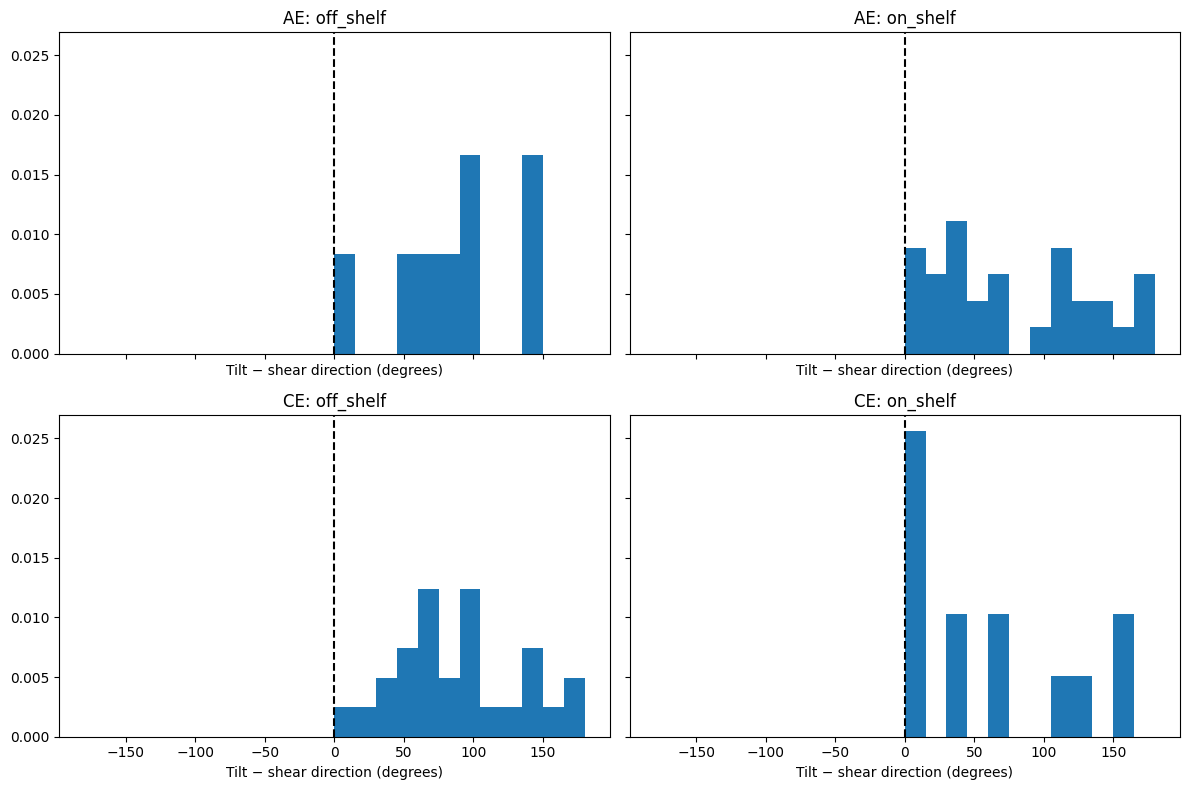

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
bins = np.arange(-180, 181, 15)
for ax, ((cyc, shelf), part) in zip(axes.flat, data.groupby(["Cyc", "ShelfRegime"])):
    eddy_offsets = part.groupby("Eddy")["ann_500_tilt_shear_offset"].apply(tilt.circular_mean_deg_true_north)
    ax.hist(eddy_offsets, bins=bins, density=True)
    ax.axvline(0, color="black", ls="--")
    ax.set(title=f"{cyc}: {shelf}", xlabel="Tilt − shear direction (degrees)")
plt.tight_layout()


In [5]:
for method in mech.BACKGROUND_PAIRS:
    data = mech.add_accumulated_shear(data, method=method, windows=(5, 10, 20, 30))

accum_offsets = [c for c in data if c.endswith("d_offset")]
accum_summary = mech.circular_offset_summary(data, accum_offsets, group=("Cyc", "ShelfRegime"))
display(accum_summary.sort_values("resultant_length", ascending=False).head(30))


,Cyc,ShelfRegime,metric,eddies,mean_offset_deg,resultant_length,median_abs_offset_deg
40,AE,on_shelf,full_200_accum_5d_offset,368,-122.570549,0.340459,217.311318
41,AE,on_shelf,full_200_accum_10d_offset,368,-116.076190,0.330547,222.296073
89,CE,on_shelf,full_200_accum_10d_offset,531,101.966673,0.324949,123.167276
84,CE,on_shelf,clim_500_accum_5d_offset,531,89.083967,0.324606,123.438876
85,CE,on_shelf,clim_500_accum_10d_offset,531,94.012208,0.323209,121.508141
94,CE,on_shelf,full_500_accum_20d_offset,531,98.012342,0.322171,123.770217
90,CE,on_shelf,full_200_accum_20d_offset,531,106.571605,0.321967,128.502074
44,AE,on_shelf,full_500_accum_5d_offset,368,-146.547332,0.318699,204.668102
95,CE,on_shelf,full_500_accum_30d_offset,531,101.345438,0.317676,127.926858
42,AE,on_shelf,full_200_accum_20d_offset,368,-109.789651,0.317411,228.397989


In [6]:
# Component-level test: a mechanism must predict both direction and distance.
import statsmodels.formula.api as smf

rows = []
for (cyc, shelf), part in data.groupby(["Cyc", "ShelfRegime"]):
    for window in (5, 10, 20, 30):
        prefix = f"ann_500_accum_{window}d"
        use = part.dropna(subset=["tilt_east_km", "tilt_north_km", f"{prefix}_east_km", f"{prefix}_north_km"])
        for component in ("east", "north"):
            fit = smf.gee(
                f"tilt_{component}_km ~ {prefix}_{component}_km",
                groups="Eddy", data=use,
            ).fit()
            term = f"{prefix}_{component}_km"
            rows.append({"Cyc": cyc, "ShelfRegime": shelf, "window": window,
                         "component": component, "n": len(use), "beta": fit.params[term],
                         "ci_low": fit.conf_int().loc[term, 0], "ci_high": fit.conf_int().loc[term, 1]})
component_tests = pd.DataFrame(rows)
display(component_tests)


,Cyc,ShelfRegime,window,component,n,beta,ci_low,ci_high
0,AE,off_shelf,5,east,46542,-0.069504,-0.110307,-0.028701
1,AE,off_shelf,5,north,46542,-0.089650,-0.125282,-0.054017
2,AE,off_shelf,10,east,46542,-0.038389,-0.067343,-0.009435
3,AE,off_shelf,10,north,46542,-0.058405,-0.084204,-0.032607
4,AE,off_shelf,20,east,46542,-0.016645,-0.036588,0.003299
5,AE,off_shelf,20,north,46542,-0.039194,-0.057714,-0.020673
6,AE,off_shelf,30,east,46542,-0.010651,-0.026615,0.005313
7,AE,off_shelf,30,north,46542,-0.031941,-0.047450,-0.016432
8,AE,on_shelf,5,east,7065,-0.058494,-0.147124,0.030135
9,AE,on_shelf,5,north,7065,-0.008066,-0.086189,0.070056


## Decision rule

Support for differential advection requires convergence of: (1) offsets concentrated near 0°, (2) positive component slopes, (3) improved results for a physically plausible trailing window, and (4) a within-eddy relationship. Treat on-shelf annulus results cautiously because coastal truncation can bias the sampled current offshore.
